In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/doctamper/DocTamperV1-TrainingSet/lock.mdb
/kaggle/input/doctamper/DocTamperV1-TrainingSet/data.mdb
/kaggle/input/doctamper/DocTamperV1-TestingSet/lock.mdb
/kaggle/input/doctamper/DocTamperV1-TestingSet/data.mdb
/kaggle/input/doctamper/DocTamperV1-SCD/lock.mdb
/kaggle/input/doctamper/DocTamperV1-SCD/data.mdb
/kaggle/input/doctamper/DocTamperV1-FCD/lock.mdb
/kaggle/input/doctamper/DocTamperV1-FCD/data.mdb


# DeepFake V2

In [10]:
#### Cell 0 INSTALL DEPENDENCIES

# timm: For the Xception model
# lmdb: To read the compressed dataset
# grad-cam: For the Explainable AI heatmaps
!pip install timm lmdb grad-cam -q

# --- IMPORTS ---
import os
import io
import time
import random
import lmdb
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, ImageChops, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm.notebook import tqdm

# Import timm for Xception
import timm

# Import Grad-CAM for Visualization
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- CONFIGURATION ---
# Set device to GPU (Target: T4 x2 or P100)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# Random Seed for Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("✅ Libraries installed and Seed set.")

✅ Using device: cuda
✅ Libraries installed and Seed set.


--- Checking Paths ---
✅ Found Training DB: /kaggle/input/doctamper/DocTamperV1-TrainingSet

--- Visualizing First Image from /kaggle/input/doctamper/DocTamperV1-TrainingSet ---
Attempting to read key: image-000000000
Verdict: FAKE (Tampered regions detected in mask)


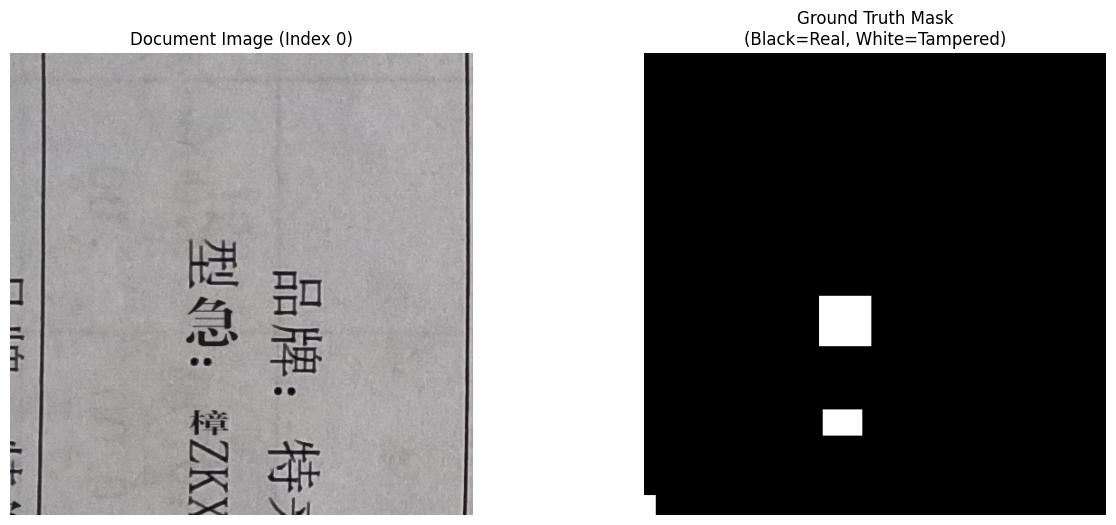

Image Size: (512, 512)


In [11]:
# Cell 1 Groung truth visualization

import os
import lmdb
import io
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Find the exact path for the Training Set
print("--- Checking Paths ---")
base_path = '/kaggle/input'
TRAIN_PATH = None

for root, dirs, files in os.walk(base_path):
    for name in files:
        if name.endswith('data.mdb'):
            full_path = os.path.dirname(os.path.join(root, name))
            # We prioritize the training set
            if "TrainingSet" in full_path:
                TRAIN_PATH = full_path
                print(f"✅ Found Training DB: {TRAIN_PATH}")

# 2. Visualize an Image
if TRAIN_PATH:
    print(f"\n--- Visualizing First Image from {TRAIN_PATH} ---")
    
    env = lmdb.open(TRAIN_PATH, readonly=True, lock=False)
    with env.begin() as txn:
        # We grab index 0. The format is 'image-000000000'
        # You can change 'index' here to look at other images (e.g., 10, 100, 500)
        index = 0
        
        img_key = f'image-{index:09d}'.encode('utf-8')
        lbl_key = f'label-{index:09d}'.encode('utf-8')
        
        print(f"Attempting to read key: {img_key.decode('utf-8')}")
        
        img_bin = txn.get(img_key)
        lbl_bin = txn.get(lbl_key)
        
        if img_bin:
            # Decode Image
            image = Image.open(io.BytesIO(img_bin)).convert('RGB')
            
            # Setup Plot
            fig, ax = plt.subplots(1, 2, figsize=(15, 6))
            
            # Show Original Image
            ax[0].imshow(image)
            ax[0].set_title(f"Document Image (Index {index})")
            ax[0].axis('off')
            
            # Show Tampering Mask (if available)
            if lbl_bin:
                mask = Image.open(io.BytesIO(lbl_bin)).convert('L')
                ax[1].imshow(mask, cmap='gray')
                ax[1].set_title("Ground Truth Mask\n(Black=Real, White=Tampered)")
                ax[1].axis('off')
                
                # Check Verdict
                mask_arr = np.array(mask)
                if np.max(mask_arr) > 0:
                    print("Verdict: FAKE (Tampered regions detected in mask)")
                else:
                    print("Verdict: REAL (No tampering detected)")
            else:
                ax[1].text(0.5, 0.5, 'No Mask Found', ha='center', va='center')
                ax[1].set_title("Ground Truth Mask")
                print("⚠️ Warning: Label/Mask key not found for this index.")

            plt.show()
            print(f"Image Size: {image.size}")
            
        else:
            print("❌ Error: Could not retrieve image bytes. Check Key format.")
    env.close()
else:
    print("❌ Error: Could not find TrainingSet path in /kaggle/input.")

In [12]:
# Cell 2 ELA definition

# --- 1. DEFINE ELA TRANSFORMATION LOGIC ---
def get_ela_tensor(img, quality=90):
    """
    Converts a PIL RGB Image -> ELA Image -> PyTorch Tensor
    This reveals compression artifacts (pasted text looks brighter/noisier).
    """
    # 1. Save to buffer to simulate compression
    buffer = io.BytesIO()
    img.save(buffer, 'JPEG', quality=quality)
    buffer.seek(0)
    
    # 2. Calculate ELA (Difference betwen Original and Compressed)
    img_compressed = Image.open(buffer)
    ela_img = ImageChops.difference(img, img_compressed)
    
    # 3. Enhance visibility (Scaling pixel values to be visible)
    extrema = ela_img.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    
    ela_img = ImageEnhance.Brightness(ela_img).enhance(scale)
    
    # 4. Convert to Tensor immediately
    return transforms.functional.to_tensor(ela_img)

# --- 2. DEFINE DATASET CLASS (LMDB READER) ---
class ELADataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform # Geometric transforms (Resize/Flip)
        self.envs = {} # Cache for LMDB environments

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # Retry logic to handle occasional corrupt keys in large datasets
        for attempt in range(3):
            try:
                curr_idx = (idx + attempt) % len(self.data_list)
                lmdb_path, key, label = self.data_list[curr_idx]

                # Open Environment if not open
                if lmdb_path not in self.envs:
                    self.envs[lmdb_path] = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, meminit=False)
                
                env = self.envs[lmdb_path]
                with env.begin(write=False) as txn:
                    img_bytes = txn.get(key.encode('utf-8'))
                    if img_bytes is None: continue # Skip if empty
                    
                    # Load Image
                    image = Image.open(io.BytesIO(img_bytes)).convert('RGB')
                    
                    # Apply Geometric Transforms (Resize/Flip) FIRST
                    if self.transform:
                        image = self.transform(image)
                    
                    # Convert to ELA (This returns a Tensor)
                    image_tensor = get_ela_tensor(image)
                    
                    # Normalize (Standard ImageNet means work fine for ELA too)
                    image_tensor = transforms.Normalize([0.485, 0.456, 0.406], 
                                                     [0.229, 0.224, 0.225])(image_tensor)
                    
                    return image_tensor, torch.tensor(label, dtype=torch.float32)
            except Exception:
                continue # Try next index
        
        # Fallback (should rarely happen)
        return torch.zeros((3, 256, 256)), torch.tensor(label, dtype=torch.float32)

# # --- 3. DATA PREPARATION & BALANCING ---
# print("--- Preparing Data Lists ---")

# # Define Paths (Kaggle Specific)
# SCD_PATH = '/kaggle/input/doctamper/DocTamperV1-SCD' # Real
# FCD_PATH = '/kaggle/input/doctamper/DocTamperV1-FCD' # Fake

# # Generate File Lists
# # We know FCD has ~4001 images and SCD has ~36000
# fake_data = []
# for i in range(4001):
#     key = f"image-{i:09d}"
#     fake_data.append((FCD_PATH, key, 1)) # Label 1 = Fake

# real_data = []
# for i in range(36001):
#     key = f"image-{i:09d}"
#     real_data.append((SCD_PATH, key, 0)) # Label 0 = Real

# # BALANCE: Take random reals equal to the number of fakes
# random.seed(42)
# real_data_balanced = random.sample(real_data, len(fake_data))
# full_dataset = fake_data + real_data_balanced

# # Split into Train (80%) and Validation (20%)
# train_data, val_data = train_test_split(full_dataset, test_size=0.2, random_state=42, shuffle=True)

# print(f"✅ Data Balanced: {len(fake_data)} Fakes, {len(real_data_balanced)} Reals.")
# print(f"✅ Train Set: {len(train_data)} images | Val Set: {len(val_data)} images")

# # --- 4. CREATE LOADERS ---
# # We resize to 256x256 before ELA processing
# ela_transforms = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.RandomHorizontalFlip()
# ])

# train_ds_ela = ELADataset(train_data, transform=ela_transforms)
# val_ds_ela = ELADataset(val_data, transform=ela_transforms)

# BATCH_SIZE = 32
# train_loader_ela = DataLoader(train_ds_ela, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
# val_loader_ela = DataLoader(val_ds_ela, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# print("✅ DataLoaders Ready.")

# --- 3. DATA PREPARATION & BALANCING ---
print("--- Preparing Data Lists ---")

# Define Paths (Kaggle Specific)
SCD_PATH = '/kaggle/input/doctamper/DocTamperV1-SCD' # Real
FCD_PATH = '/kaggle/input/doctamper/DocTamperV1-FCD' # Fake

# Generate File Lists
fake_data = []
for i in range(4001):
    key = f"image-{i:09d}"
    fake_data.append((FCD_PATH, key, 1)) # Label 1 = Fake

real_data = []
for i in range(36001):
    key = f"image-{i:09d}"
    real_data.append((SCD_PATH, key, 0)) # Label 0 = Real

# BALANCE: Take random reals equal to the number of fakes
random.seed(42)
real_data_balanced = random.sample(real_data, len(fake_data))
full_dataset = fake_data + real_data_balanced

# Split into Train (80%), Validation (10%), and Test (10%)
train_data, temp_data = train_test_split(full_dataset, test_size=0.2, random_state=42, shuffle=True)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42, shuffle=True)

print(f"✅ Data Balanced: {len(fake_data)} Fakes, {len(real_data_balanced)} Reals.")
print(f"✅ Train Set: {len(train_data)} images | Val Set: {len(val_data)} images | Test Set: {len(test_data)} images")

# --- 4. CREATE LOADERS ---
# We resize to 256x256 before ELA processing
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip()
])

# For validation and testing, use deterministic transforms (no random flips)
val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256))
])

train_ds_ela = ELADataset(train_data, transform=train_transforms)
val_ds_ela = ELADataset(val_data, transform=val_test_transforms)
test_ds_ela = ELADataset(test_data, transform=val_test_transforms)

BATCH_SIZE = 32
train_loader_ela = DataLoader(train_ds_ela, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_ela = DataLoader(val_ds_ela, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_ela = DataLoader(test_ds_ela, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("✅ DataLoaders Ready.")


--- Preparing Data Lists ---
✅ Data Balanced: 4001 Fakes, 4001 Reals.
✅ Train Set: 6401 images | Val Set: 800 images | Test Set: 801 images
✅ DataLoaders Ready.


In [13]:
# Cell 3 Training XceptionNet

# --- 1. MODEL FACTORY ---
def get_model(model_name, num_classes=1):
    print(f"--- Initializing {model_name} ---")
    model = None
    
    if model_name == 'resnet50':
        model = models.resnet50(pretrained=True)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'densenet121':
        model = models.densenet121(pretrained=True)
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'xception':
        # Using timm for Xception
        model = timm.create_model('xception', pretrained=True)
        num_ftrs = model.get_classifier().in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    else:
        raise ValueError(f"Model {model_name} not implemented")
    
    return model.to(device)

# --- 2. TRAINING ENGINE ---
def train_model(model, train_loader, val_loader, criterion, optimizer, model_name, num_epochs=5):
    since = time.time()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    
    print(f"\nStarting training for {model_name}...")
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            all_preds = []
            all_labels = []

            # Loop over data
            # We use a progress bar for Training only to keep output clean
            iterator = tqdm(dataloader, desc=phase, leave=False) if phase == 'train' else dataloader
            
            for inputs, labels in iterator:
                inputs = inputs.to(device)
                labels = labels.to(device).unsqueeze(1) # Reshape for BCE

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                
                # Metrics
                preds = torch.sigmoid(outputs) > 0.5
                if phase == 'val':
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                print(f"   {phase} Loss: {epoch_loss:.4f}")
            else:
                val_acc = accuracy_score(all_labels, all_preds)
                val_f1 = f1_score(all_labels, all_preds)
                
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(val_acc)
                history['val_f1'].append(val_f1)
                
                print(f"   {phase} Loss: {epoch_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    time_elapsed = time.time() - since
    print(f'{model_name} complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return history

print("✅ Model Factory and Training Engine Ready.")

✅ Model Factory and Training Engine Ready.


In [ ]:
# Cell 4 Train Xception (Forensic ELA Mode)

# --- CONFIGURATION ---
LEARNING_RATE = 0.00015
EPOCHS = 15

# --- INITIALIZE MODEL ---
# We use Xception because it outperformed ResNet/DenseNet in our tests
ela_model = get_model('xception')

# --- OPTIMIZER & LOSS ---
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(ela_model.parameters(), lr=LEARNING_RATE)

# --- START TRAINING ---
print(f"🚀 Starting Forensic Training on {len(train_ds_ela)} images...")
hist_ela = train_model(
    ela_model, 
    train_loader_ela, 
    val_loader_ela, 
    criterion, 
    optimizer, 
    model_name='Xception_ELA', 
    num_epochs=EPOCHS
)

# --- SAVE WEIGHTS ---
save_path = 'xception_ela_doctamper_latest.pth'
torch.save(ela_model.state_dict(), save_path)
print(f"✅ Training Complete. Model saved to: {save_path}")

--- Initializing xception ---


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


🚀 Starting Forensic Training on 6401 images...

Starting training for Xception_ELA...
Epoch 1/15


train:   0%|          | 0/201 [00:00<?, ?it/s]

# Iteration Results
--- Initializing xception ---
🚀 Starting Forensic Training on 6401 images...

Starting training for Xception_ELA...
Epoch 1/5
   train Loss: 0.1320
   val Loss: 0.0943 | Acc: 0.9263 | F1: 0.9182
Epoch 2/5
   train Loss: 0.0919
   val Loss: 0.0943 | Acc: 0.9263 | F1: 0.9182
Epoch 3/5
   train Loss: 0.0917
   val Loss: 0.0940 | Acc: 0.9263 | F1: 0.9182
Epoch 4/5
   train Loss: 0.0907
   val Loss: 0.0942 | Acc: 0.9263 | F1: 0.9182

--- Generating Forensic Analysis for 3 Fakes ---


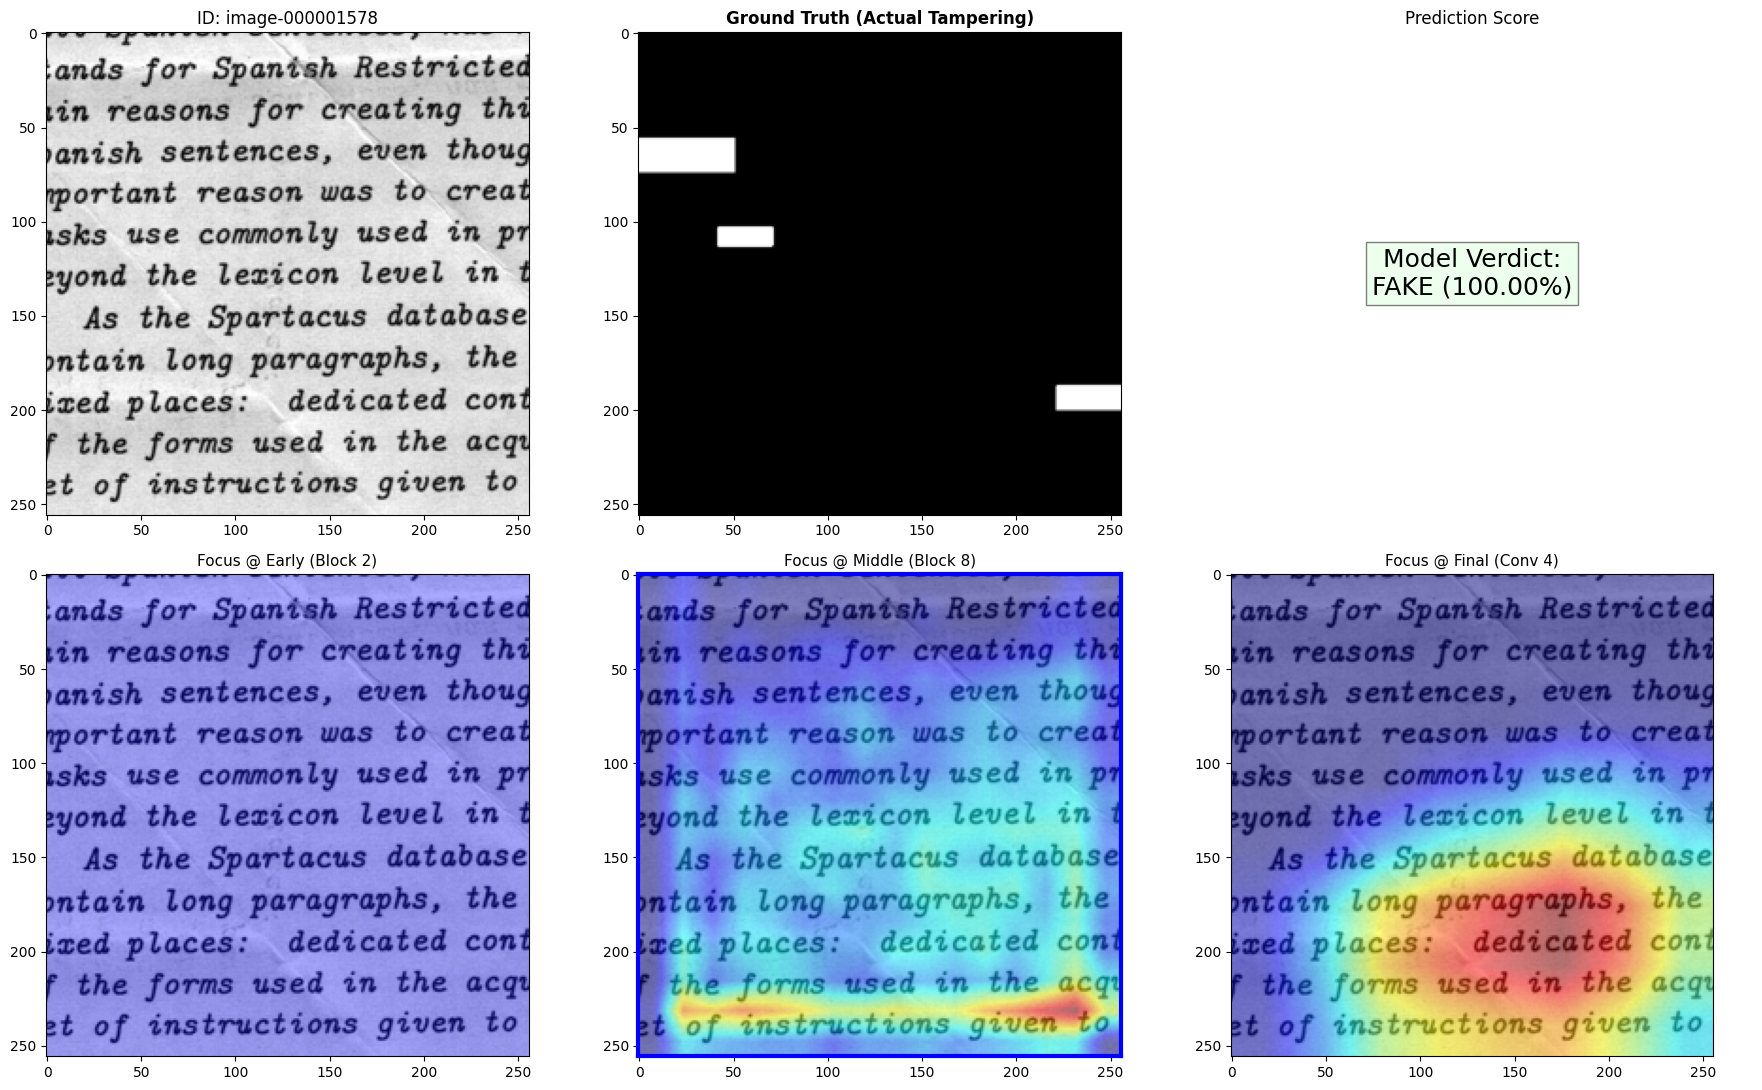

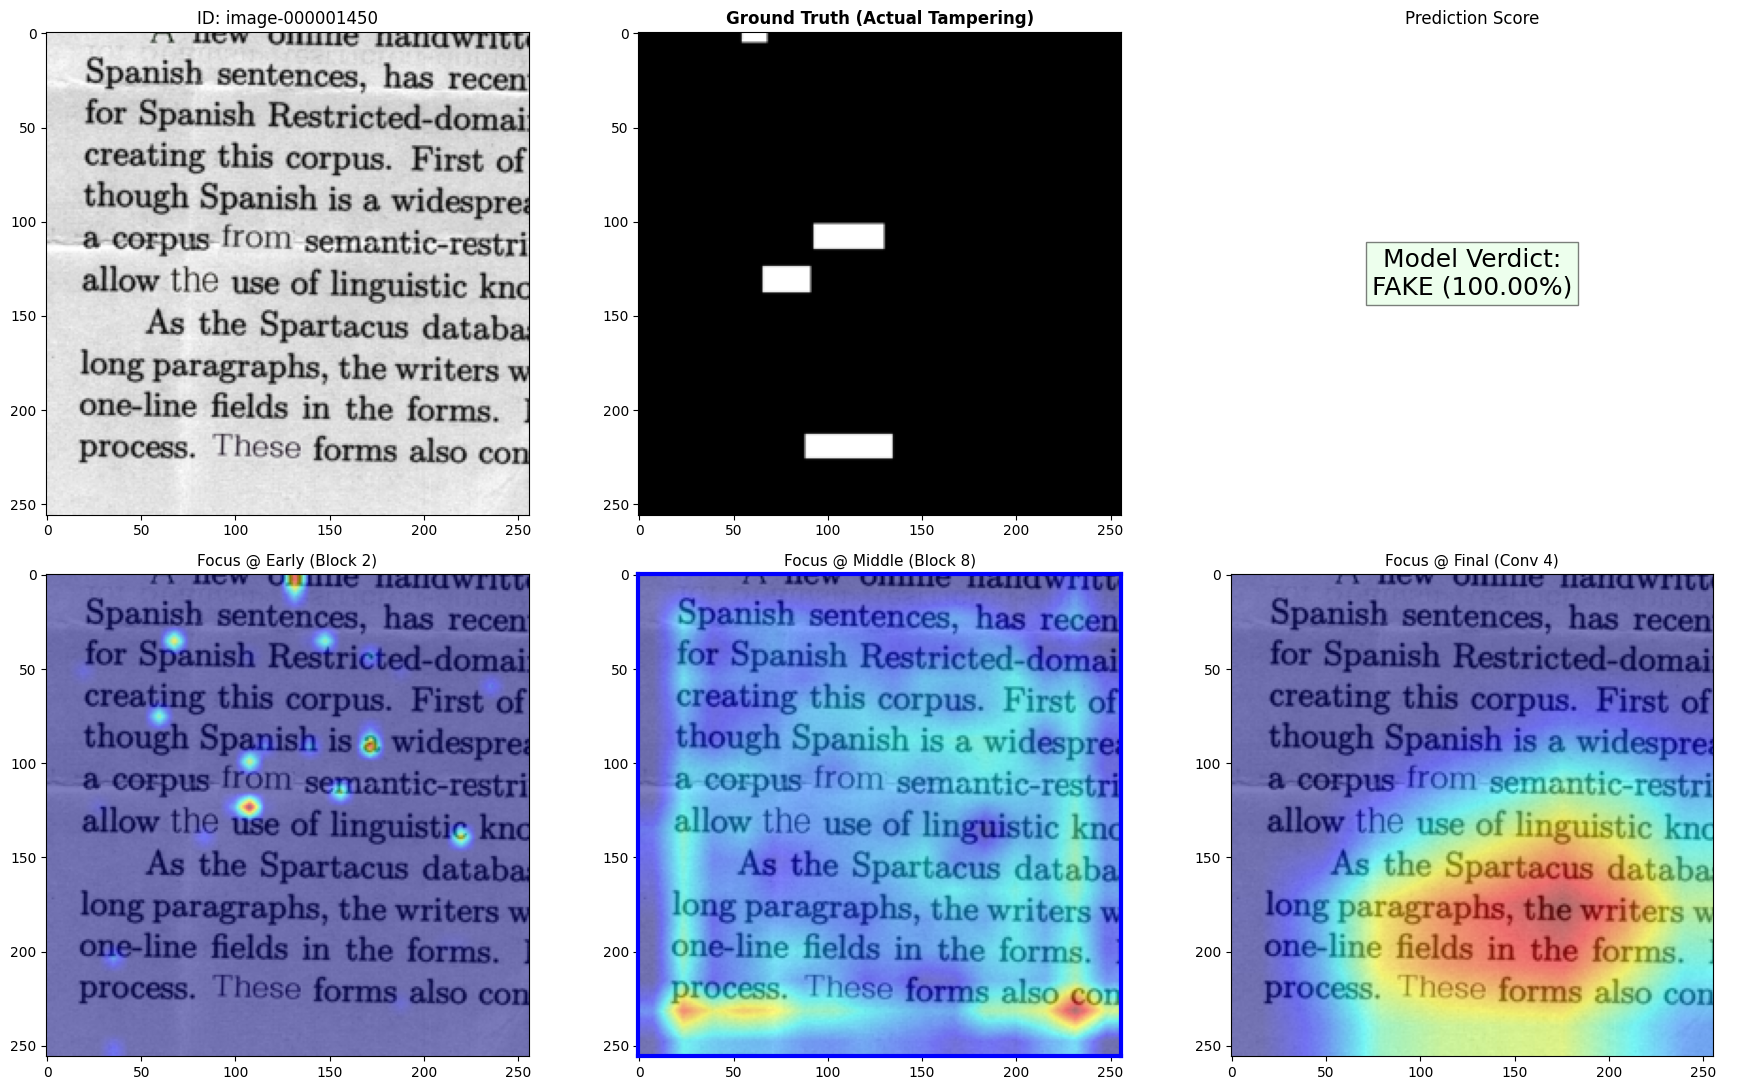

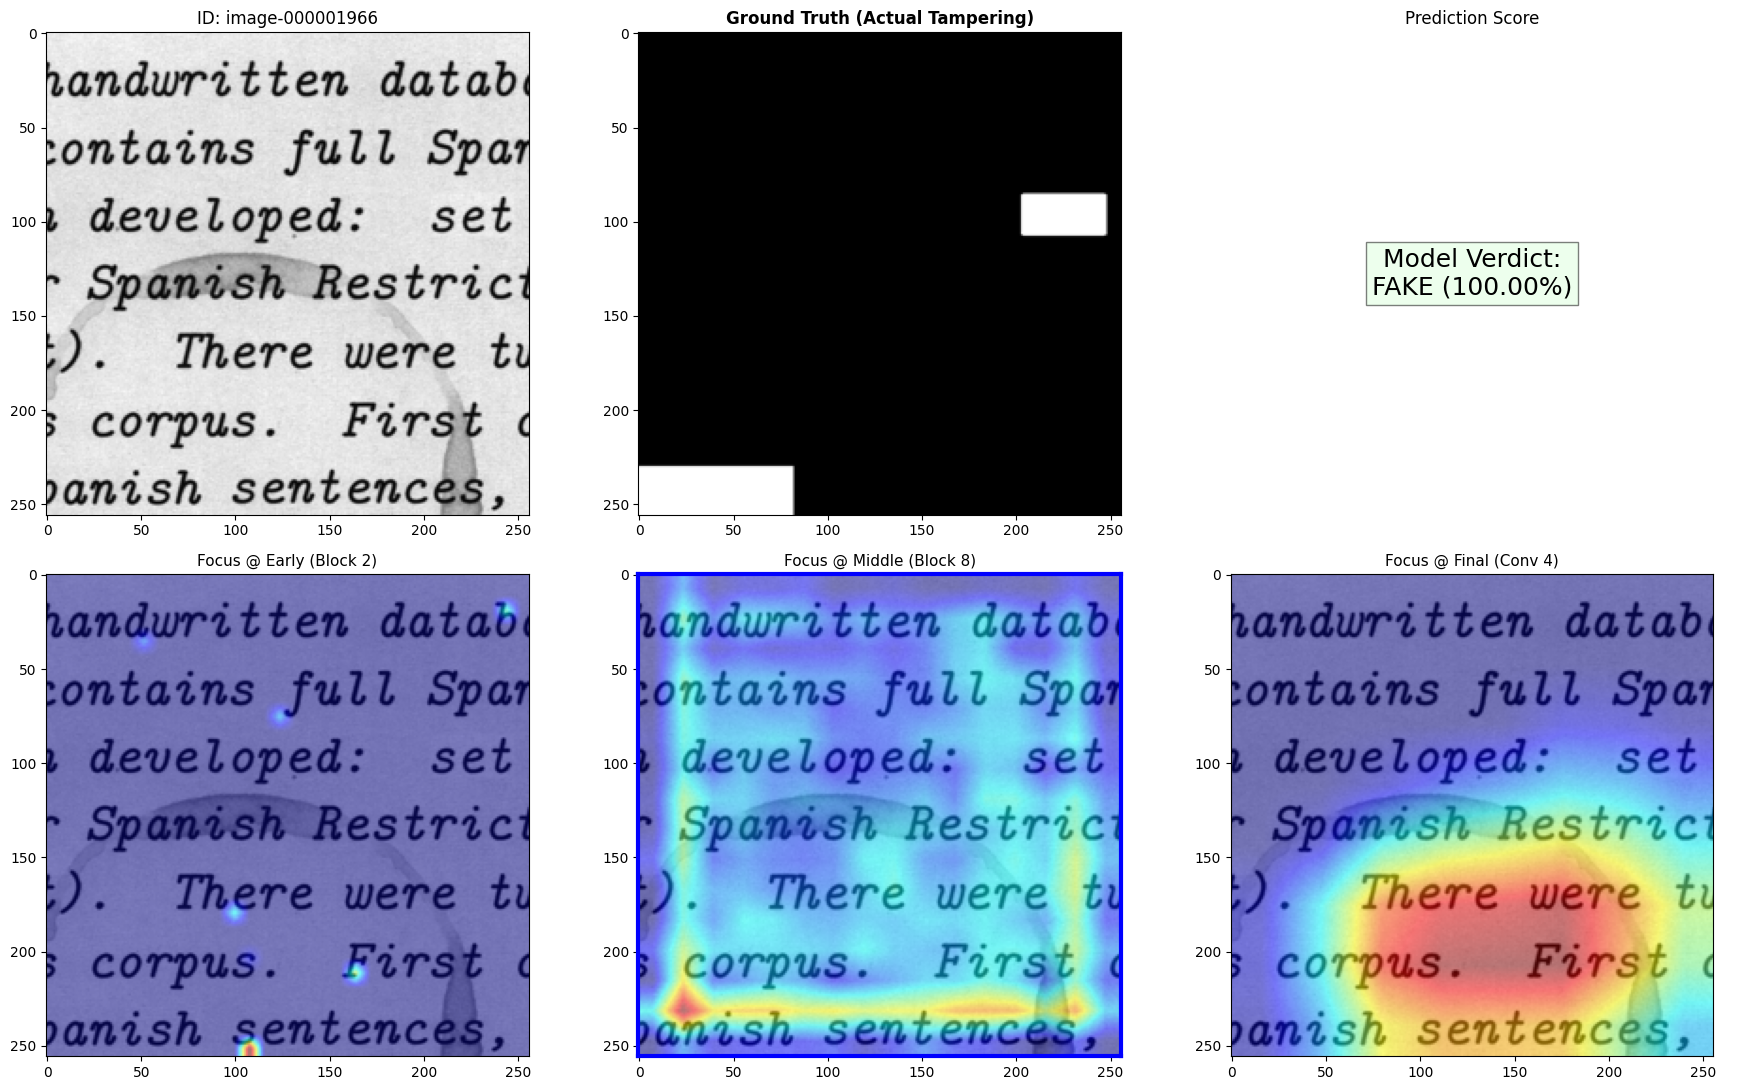

In [11]:
# Cell 5 GENERATE FORENSIC REPORT VISUALIZATIONS using GRADCAM

import matplotlib.pyplot as plt
import numpy as np
import io
import lmdb
import torch
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def generate_forensic_report(model, dataset, num_samples=3):
    model.eval()
    
    # --- Define Layers to Inspect ---
    # We look at Early, Middle, and Final layers to show the "decision path"
    layers_to_try = []
    
    try: layers_to_try.append(("Early (Block 2)", model.block2)) 
    except: pass
    
    try: layers_to_try.append(("Middle (Block 8)", model.block8))
    except: pass
    
    try: layers_to_try.append(("Final (Conv 4)", model.conv4))
    except: pass

    # Fallback if specific blocks aren't found
    if not layers_to_try:
        all_modules = list(model.modules())
        layers_to_try = [
            ("Early", all_modules[20]),
            ("Middle", all_modules[60]),
            ("Final", all_modules[-2])
        ]

    print(f"--- Generating Forensic Analysis for {num_samples} Fakes ---")
    
    count = 0
    # Iterate through the dataset
    for i in range(len(dataset)):
        if count >= num_samples: break
        
        ela_tensor, label = dataset[i]
        
        # Filter: Only look at FAKES (Label 1)
        if label != 1: continue 
        
        # --- 1. Get Model Prediction Score ---
        input_tensor = ela_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_tensor)
            prob = torch.sigmoid(logits).item()
            
        pred_label = "FAKE" if prob > 0.5 else "REAL"
        score_text = f"{pred_label} ({prob*100:.2f}%)"
        
        # --- 2. Get Raw Image & Mask ---
        lmdb_path, img_key, _ = dataset.data_list[i]
        mask_key = img_key.replace('image-', 'label-')
        
        try:
            env = lmdb.open(lmdb_path, readonly=True, lock=False)
            with env.begin() as txn:
                img_bytes = txn.get(img_key.encode('utf-8'))
                original_img = Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((256, 256))
                
                mask_bytes = txn.get(mask_key.encode('utf-8'))
                if mask_bytes:
                    gt_mask = Image.open(io.BytesIO(mask_bytes)).convert('L').resize((256, 256))
                else: continue 
            env.close()
        except: continue
            
        # --- 3. Plotting ---
        # 2 Rows: Top = Evidence, Bottom = AI Analysis
        fig, axes = plt.subplots(2, 3, figsize=(18, 11))
        
        # -- Row 1: The Evidence --
        axes[0,0].imshow(original_img)
        axes[0,0].set_title(f"ID: {img_key}", fontsize=12)
        
        axes[0,1].imshow(gt_mask, cmap='gray')
        axes[0,1].set_title("Ground Truth (Actual Tampering)", fontsize=12, fontweight='bold')
        
        # Prediction Box
        axes[0,2].text(0.5, 0.5, f"Model Verdict:\n{score_text}", 
                       fontsize=18, ha='center', va='center', 
                       bbox=dict(facecolor='#ddffdd' if prob > 0.5 else '#ffdddd', alpha=0.5))
        axes[0,2].set_title("Prediction Score")
        axes[0,2].axis('off')
        
        # -- Row 2: The AI "Brain" --
        targets = [ClassifierOutputTarget(0)] # Target "Real" class (gradients show deviation)
        
        for idx, (layer_name, layer_obj) in enumerate(layers_to_try):
            try:
                cam = GradCAM(model=model, target_layers=[layer_obj])
                grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
                
                rgb_float = np.array(original_img) / 255.0
                heatmap = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)
                
                axes[1, idx].imshow(heatmap)
                axes[1, idx].set_title(f"Focus @ {layer_name}", fontsize=11)
                
                # Highlight the "Middle" layer (Best for forensics)
                if "Middle" in layer_name:
                    for spine in axes[1, idx].spines.values():
                        spine.set_edgecolor('blue')
                        spine.set_linewidth(3)

            except Exception as e:
                axes[1, idx].text(0.5, 0.5, "Layer Error", ha='center')
        
        plt.tight_layout()
        plt.show()
        count += 1

# Run Report Generation
if 'ela_model' in locals():
    generate_forensic_report(ela_model, train_ds_ela, num_samples=3)
else:
    print("❌ Model not found. Please run the training cell first.")

In [ ]:
# Cell 5 Validation and Testing Split Evaluation

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, 
    recall_score, confusion_matrix, roc_curve, auc, 
    classification_report
)
from tqdm.notebook import tqdm

def evaluate_model_on_loader(model, dataloader, device, desc="Evaluating"):
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []
    running_loss = 0.0
    criterion = torch.nn.BCEWithLogitsLoss()
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=desc):
            inputs = inputs.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            
            probs = torch.sigmoid(outputs)
            preds = probs > 0.5
            
            all_probs.extend(probs.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            
    avg_loss = running_loss / len(dataloader.dataset)
    
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall': recall_score(all_labels, all_preds),
        'labels': np.array(all_labels),
        'preds': np.array(all_preds),
        'probs': np.array(all_probs)
    }
    return metrics

def plot_evaluation_results(val_metrics, test_metrics):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Confusion Matrix - Validation
    cm_val = confusion_matrix(val_metrics['labels'], val_metrics['preds'])
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
    axes[0, 0].set_title('Confusion Matrix - Validation Set')
    axes[0, 0].set_xlabel('Predicted Label')
    axes[0, 0].set_ylabel('True Label')
    
    # 2. Confusion Matrix - Test
    cm_test = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
                xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
    axes[0, 1].set_title('Confusion Matrix - Test Set')
    axes[0, 1].set_xlabel('Predicted Label')
    axes[0, 1].set_ylabel('True Label')
    
    # 3. ROC Curve - Validation
    fpr_val, tpr_val, _ = roc_curve(val_metrics['labels'], val_metrics['probs'])
    roc_auc_val = auc(fpr_val, tpr_val)
    axes[1, 0].plot(fpr_val, tpr_val, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
    axes[1, 0].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1, 0].set_xlim([0.0, 1.0])
    axes[1, 0].set_ylim([0.0, 1.05])
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curve - Validation Set')
    axes[1, 0].legend(loc="lower right")
    
    # 4. ROC Curve - Test
    fpr_test, tpr_test, _ = roc_curve(test_metrics['labels'], test_metrics['probs'])
    roc_auc_test = auc(fpr_test, tpr_test)
    axes[1, 1].plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_test:.4f})')
    axes[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1, 1].set_xlim([0.0, 1.0])
    axes[1, 1].set_ylim([0.0, 1.05])
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].set_title('ROC Curve - Test Set')
    axes[1, 1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

# Execute evaluation using the trained model
if 'ela_model' in locals():
    model_path = 'xception_ela_doctamper_latest.pth'
    if os.path.exists(model_path):
        print(f"Loading weights from {model_path} for final evaluation...")
        ela_model.load_state_dict(torch.load(model_path, map_location=device))
        
    print("\n--- Evaluating on Validation Split ---")
    val_metrics = evaluate_model_on_loader(ela_model, val_loader_ela, device, desc="Validation Eval")
    
    print("\n--- Evaluating on Test Split ---")
    test_metrics = evaluate_model_on_loader(ela_model, test_loader_ela, device, desc="Test Eval")
    
    # Print Metrics Summary
    print("\n" + "="*50)
    print("                EVALUATION METRICS SUMMARY")
    print("="*50)
    print(f"Validation Loss:      {val_metrics['loss']:.4f} | Test Loss:      {test_metrics['loss']:.4f}")
    print(f"Validation Accuracy:  {val_metrics['accuracy']*100:.2f}% | Test Accuracy:  {test_metrics['accuracy']*100:.2f}%")
    print(f"Validation F1-Score:  {val_metrics['f1']*100:.2f}% | Test F1-Score:  {test_metrics['f1']*100:.2f}%")
    print(f"Validation Precision: {val_metrics['precision']*100:.2f}% | Test Precision: {test_metrics['precision']*100:.2f}%")
    print(f"Validation Recall:    {val_metrics['recall']*100:.2f}% | Test Recall:    {test_metrics['recall']*100:.2f}%")
    print("="*50)
    
    print("\nClassification Report (Validation Set):")
    print(classification_report(val_metrics['labels'], val_metrics['preds'], target_names=['Real (0)', 'Fake (1)']))
    
    print("\nClassification Report (Test Set):")
    print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=['Real (0)', 'Fake (1)']))
    
    plot_evaluation_results(val_metrics, test_metrics)
else:
    print("❌ Trained model 'ela_model' not found. Please train the model first.")


--- Analyzing prediction confidence for Xception ELA on Validation Data ---


Inference:   0%|          | 0/51 [00:00<?, ?it/s]

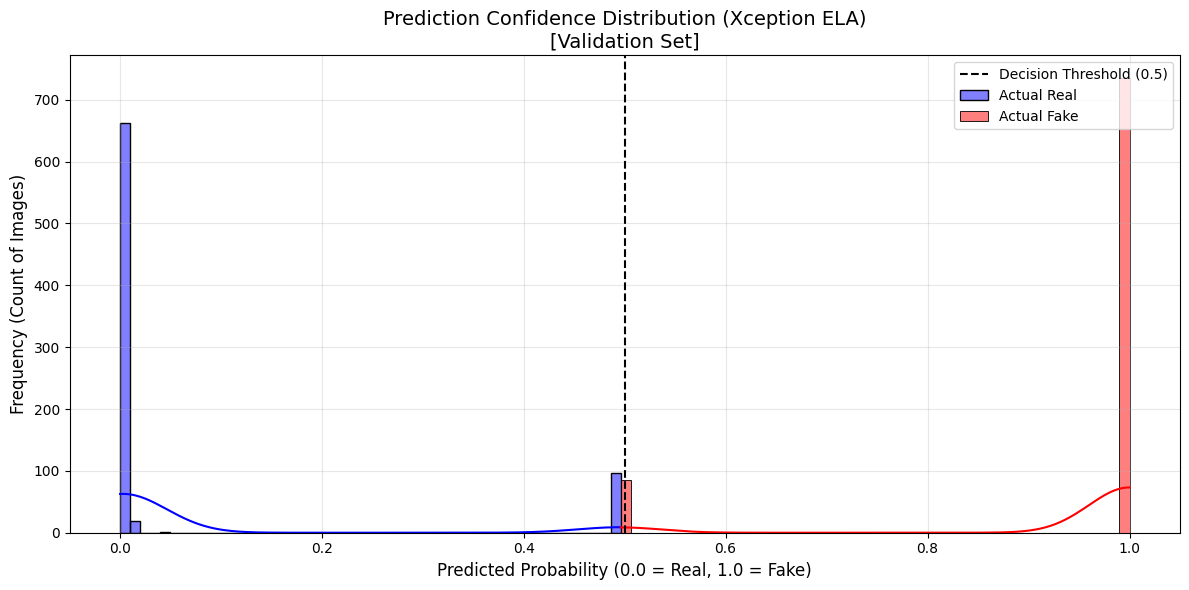

In [12]:
# Cell 6 Prediction distribution

# --- CELL 6: ROBUSTNESS CHECK (CONFIDENCE DISTRIBUTION) ---

import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

def plot_ela_prediction_distribution(model, dataset, model_name="Xception ELA"):
    # Create a temporary loader for this visualization
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)
    
    model.eval()
    all_probs = []
    true_labels = []
    
    print(f"--- Analyzing prediction confidence for {model_name} on Validation Data ---")
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Inference"):
            inputs = inputs.to(device)
            
            # Get logits and convert to probabilities (0.0 - 1.0)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            all_probs.extend(probs.flatten())
            true_labels.extend(labels.numpy())
            
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Separate the probabilities based on the Ground Truth
    real_probs = [p for p, l in zip(all_probs, true_labels) if l == 0]
    fake_probs = [p for p, l in zip(all_probs, true_labels) if l == 1]
    
    # Histogram with KDE (Kernel Density Estimate) curve
    sns.histplot(real_probs, color='blue', label='Actual Real', bins=50, alpha=0.5, kde=True)
    sns.histplot(fake_probs, color='red', label='Actual Fake', bins=50, alpha=0.5, kde=True)
    
    plt.title(f'Prediction Confidence Distribution ({model_name})\n[Validation Set]', fontsize=14)
    plt.xlabel('Predicted Probability (0.0 = Real, 1.0 = Fake)', fontsize=12)
    plt.ylabel('Frequency (Count of Images)', fontsize=12)
    
    # Add vertical line at decision threshold
    plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the Analysis on the Validation Set (Unseen Data)
if 'ela_model' in locals() and 'val_ds_ela' in locals():
    plot_ela_prediction_distribution(ela_model, val_ds_ela)
else:
    print("❌ Model or Validation Set not found. Please run previous cells.")

--- Generating LIME (SLIC Mode) for image-000001578 ---


  0%|          | 0/1000 [00:00<?, ?it/s]

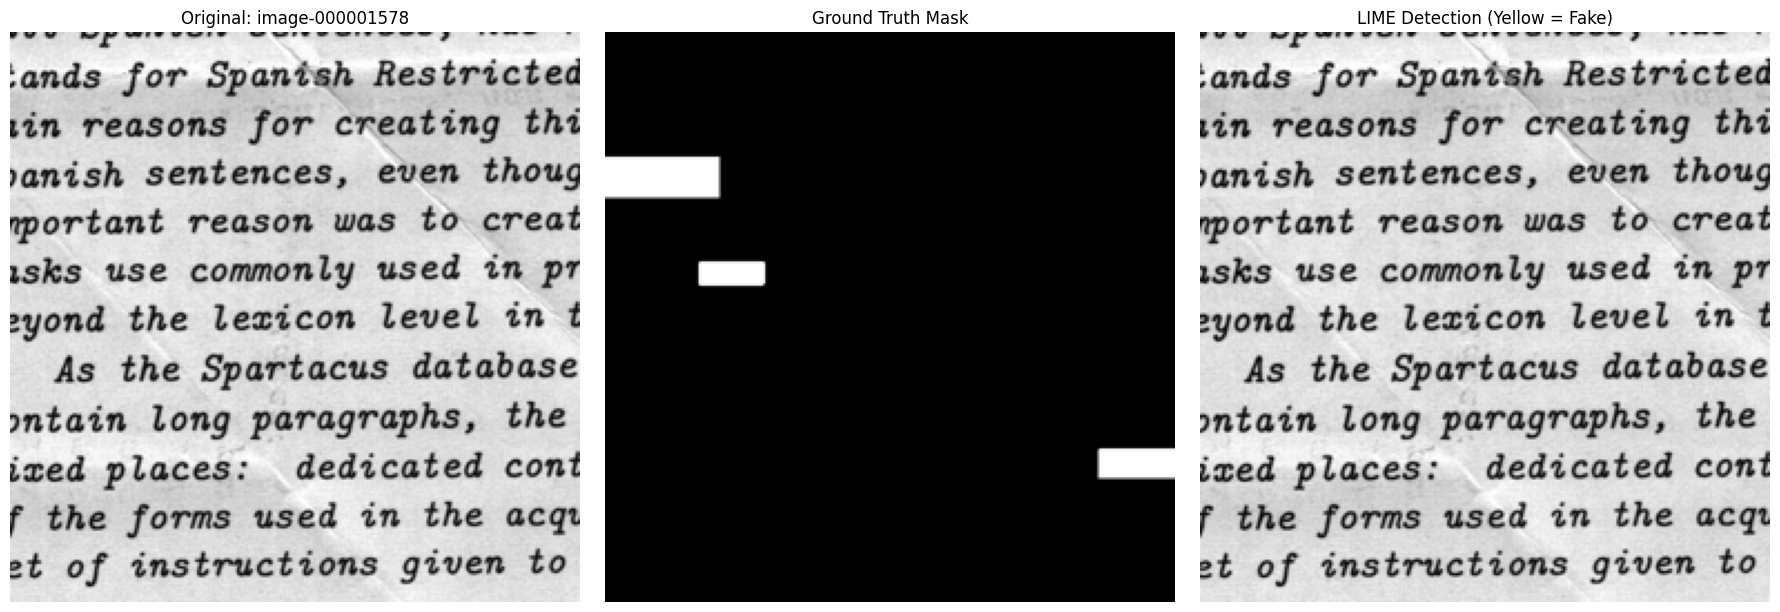

--- Generating LIME (SLIC Mode) for image-000001450 ---


  0%|          | 0/1000 [00:00<?, ?it/s]

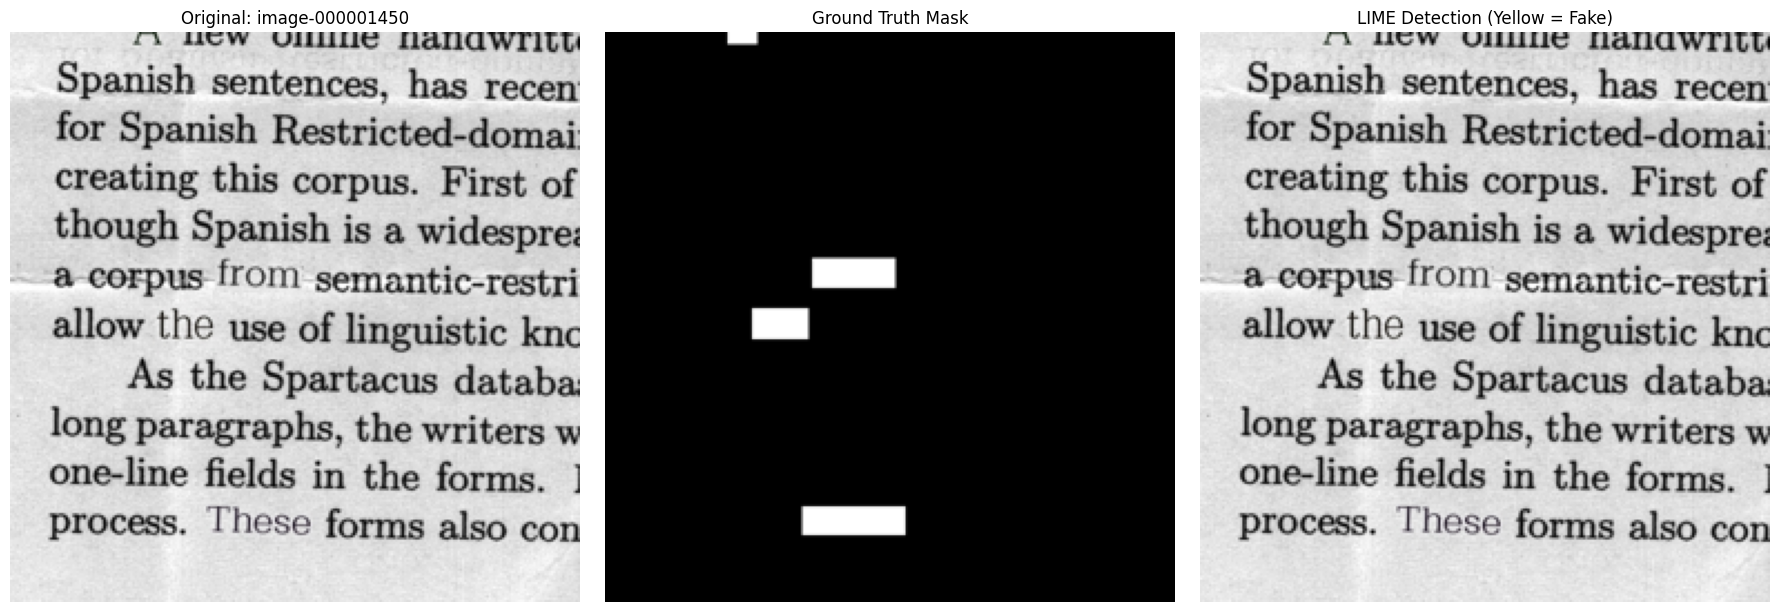

--- Generating LIME (SLIC Mode) for image-000002069 ---
--- Generating LIME (SLIC Mode) for image-000003176 ---
--- Generating LIME (SLIC Mode) for image-000001966 ---


  0%|          | 0/1000 [00:00<?, ?it/s]

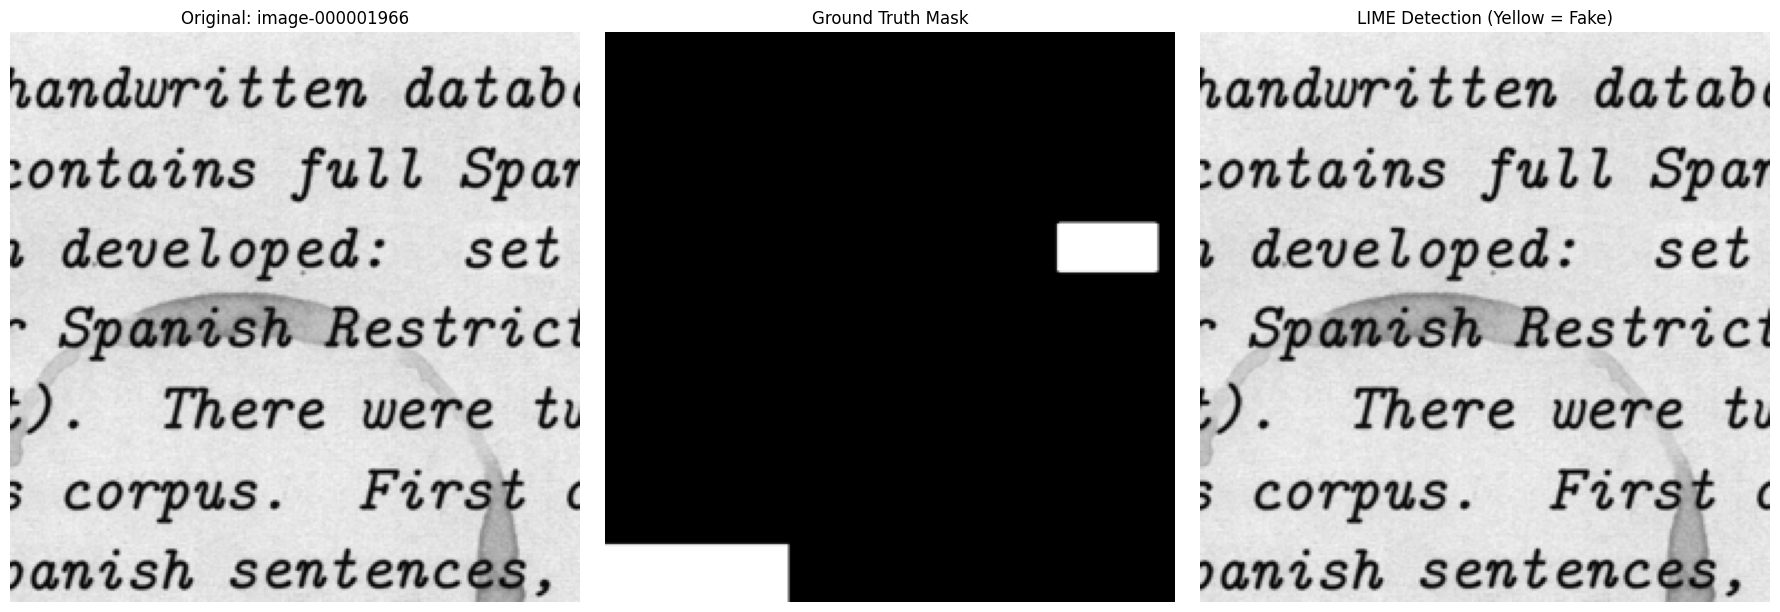

In [17]:
# Cell 7 LIME

import numpy as np
import torch
import torch.nn.functional as F
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
import matplotlib.pyplot as plt
from PIL import Image
import io
import lmdb
from torchvision import transforms

# --- 1. Define Prediction Function ---
def predict_fn(images):
    ela_model.eval()
    batch_tensors = []
    for img in images:
        if np.max(img) > 1.0: img = img / 255.0
        tensor = torch.tensor(img).permute(2, 0, 1).float()
        tensor = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(tensor)
        batch_tensors.append(tensor)
    
    batch_tensor = torch.stack(batch_tensors).to(device)
    with torch.no_grad():
        logits = ela_model(batch_tensor)
        probs = F.softmax(logits, dim=1)
    return probs.cpu().numpy()

# --- 2. Custom Segmentation for Noise/ELA ---
# This forces the image into 100 uniform segments (good for text blocks)
def segmentation_fn(image):
    return slic(image, n_segments=100, compactness=30, sigma=1, start_label=1)

# --- 3. Visualization Function ---
def visualize_lime_robust(dataset, num_samples=3):
    explainer = lime_image.LimeImageExplainer()
    
    count = 0
    for i in range(len(dataset)):
        if count >= num_samples: break
        
        ela_tensor, label = dataset[i]
        if label != 1: continue # Only check Fakes
        
        lmdb_path, img_key, _ = dataset.data_list[i]
        mask_key = img_key.replace('image-', 'label-')
        print(f"--- Generating LIME (SLIC Mode) for {img_key} ---")
        
        try:
            # Get Images
            env = lmdb.open(lmdb_path, readonly=True, lock=False)
            with env.begin() as txn:
                img_bytes = txn.get(img_key.encode('utf-8'))
                original_numpy = np.array(Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((256, 256))) / 255.0
                
                mask_bytes = txn.get(mask_key.encode('utf-8'))
                gt_mask_pil = Image.open(io.BytesIO(mask_bytes)).convert('L').resize((256, 256)) if mask_bytes else None
            env.close()
        except: continue

        # Prepare ELA for LIME
        inv_normalize = transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
        ela_numpy = inv_normalize(ela_tensor).permute(1, 2, 0).cpu().numpy()
        ela_numpy = np.clip(ela_numpy, 0, 1)

        # Run LIME with Custom Segmentation
        explanation = explainer.explain_instance(
            ela_numpy.astype('double'), 
            predict_fn, 
            top_labels=1, 
            hide_color=0, 
            num_samples=1000,
            segmentation_fn=segmentation_fn # <--- THIS IS THE KEY FIX
        )
        
        # Get Mask (Top 5 features)
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
        
        # Plot
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(original_numpy)
        axes[0].set_title(f"Original: {img_key}")
        
        axes[1].imshow(gt_mask_pil, cmap='gray')
        axes[1].set_title("Ground Truth Mask")
        
        # We increase outline thickness using 'thick' mode or just plotting carefully
        axes[2].imshow(mark_boundaries(original_numpy, mask, color=(1, 1, 0), outline_color=(0,0,1), mode='thick'))
        axes[2].set_title("LIME Detection (Yellow = Fake)")
        
        for ax in axes: ax.axis('off')
        plt.tight_layout()
        plt.show()
        count += 1

if 'ela_model' in locals():
    visualize_lime_robust(train_ds_ela, num_samples=3)

--- Initializing SHAP Explainer ---
--- Calculating SHAP values for Image 2 ---
Displaying Analysis for image-000001578...


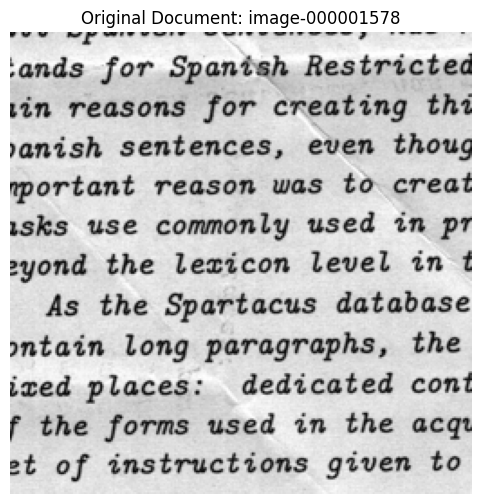

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.0].


SHAP Interpretation (Red = Evidence of Fake):


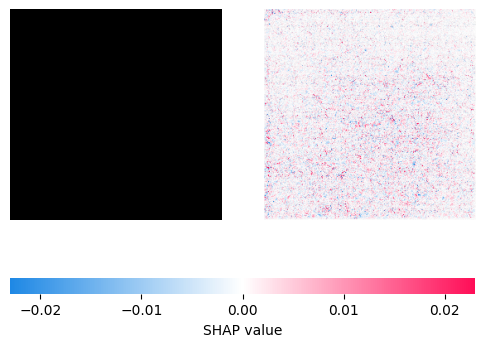

--- Calculating SHAP values for Image 7 ---
Displaying Analysis for image-000001450...


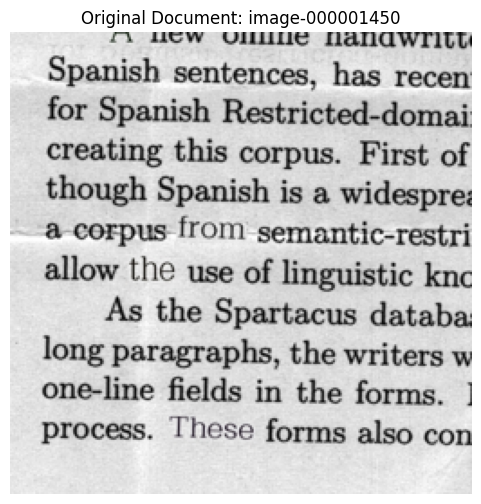

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.0].


SHAP Interpretation (Red = Evidence of Fake):


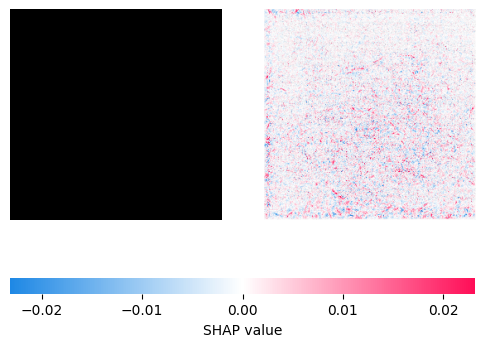

In [20]:
# Cell 8 SHAP

# --- INSTALL SHAP ---
# !pip install shap -q

import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import lmdb
import io
from PIL import Image

# --- 1. Prepare Background Data ---
def get_background_batch(dataset, n=50):
    loader = torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)
    images, labels = next(iter(loader))
    return images.to(device)

print("--- Initializing SHAP Explainer ---")
if 'ela_model' in locals():
    # Helper to get background
    background = get_background_batch(train_ds_ela, n=50)
    explainer = shap.GradientExplainer(ela_model, background)
else:
    print("❌ Model not found. Run training first.")

# --- 2. Visualization Function ---
def visualize_shap_final(dataset, num_samples=3):
    count = 0
    
    # Pre-define inverse normalization
    inv_normalize = transforms.Normalize(
       mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
       std=[1/0.229, 1/0.224, 1/0.225]
    )

    for i in range(len(dataset)):
        if count >= num_samples: break
        
        ela_tensor, label = dataset[i]
        if label != 1: continue # Only explain Fakes
        
        print(f"--- Calculating SHAP values for Image {i} ---")
        
        # A. Prepare Input
        input_tensor = ela_tensor.unsqueeze(0).to(device)
        
        # B. Compute SHAP
        shap_values = explainer.shap_values(input_tensor)
        
        if isinstance(shap_values, list):
            shap_numpy = shap_values[0]
        else:
            shap_numpy = shap_values
            
        # --- CRITICAL FIX: Handle 5D Shapes ---
        # Input Shape: (Batch, C, H, W, Classes) -> (1, 3, 256, 256, 1)
        
        if len(shap_numpy.shape) == 5:
            # Squeeze the last dimension (Classes) to get (1, 3, 256, 256)
            shap_numpy = np.squeeze(shap_numpy, axis=-1)
            
        # Now treat as 4D: (Batch, C, H, W)
        if len(shap_numpy.shape) == 4:
            # Transpose to (Batch, H, W, Channel) for plotting
            shap_display = np.transpose(shap_numpy, (0, 2, 3, 1))
        elif len(shap_numpy.shape) == 3:
            # Case 2: (Channel, H, W) -> Transpose to (H, W, Channel) -> Add Batch
            shap_display = np.transpose(shap_numpy, (1, 2, 0))
            shap_display = np.expand_dims(shap_display, axis=0)
        else:
            print(f"⚠️ Still skipping due to weird shape: {shap_numpy.shape}")
            continue

        # C. Get Original Image for Context
        lmdb_path, img_key, _ = dataset.data_list[i]
        try:
            env = lmdb.open(lmdb_path, readonly=True, lock=False)
            with env.begin() as txn:
                img_bytes = txn.get(img_key.encode('utf-8'))
                original_img = Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((256, 256))
                original_numpy = np.array(original_img) / 255.0
            env.close()
        except: continue

        # D. Prepare ELA for SHAP Plot
        ela_display_tensor = inv_normalize(ela_tensor)
        ela_display = ela_display_tensor.permute(1, 2, 0).cpu().numpy()
        ela_display = np.clip(ela_display, 0, 1)
        # Add batch dim to match shap_display
        ela_display = np.expand_dims(ela_display, axis=0)
        
        # E. Plotting
        print(f"Displaying Analysis for {img_key}...")
        
        plt.figure(figsize=(6, 6))
        plt.imshow(original_numpy)
        plt.title(f"Original Document: {img_key}")
        plt.axis('off')
        plt.show()
        
        print("SHAP Interpretation (Red = Evidence of Fake):")
        # Plot SHAP on top of the ELA Noise
        shap.image_plot(shap_display, -ela_display)
        
        count += 1

# Run the Final SHAP Analysis
if 'ela_model' in locals():
    visualize_shap_final(train_ds_ela, num_samples=2)

--- Calculating SHAP for image-000001578 (1/3) ---


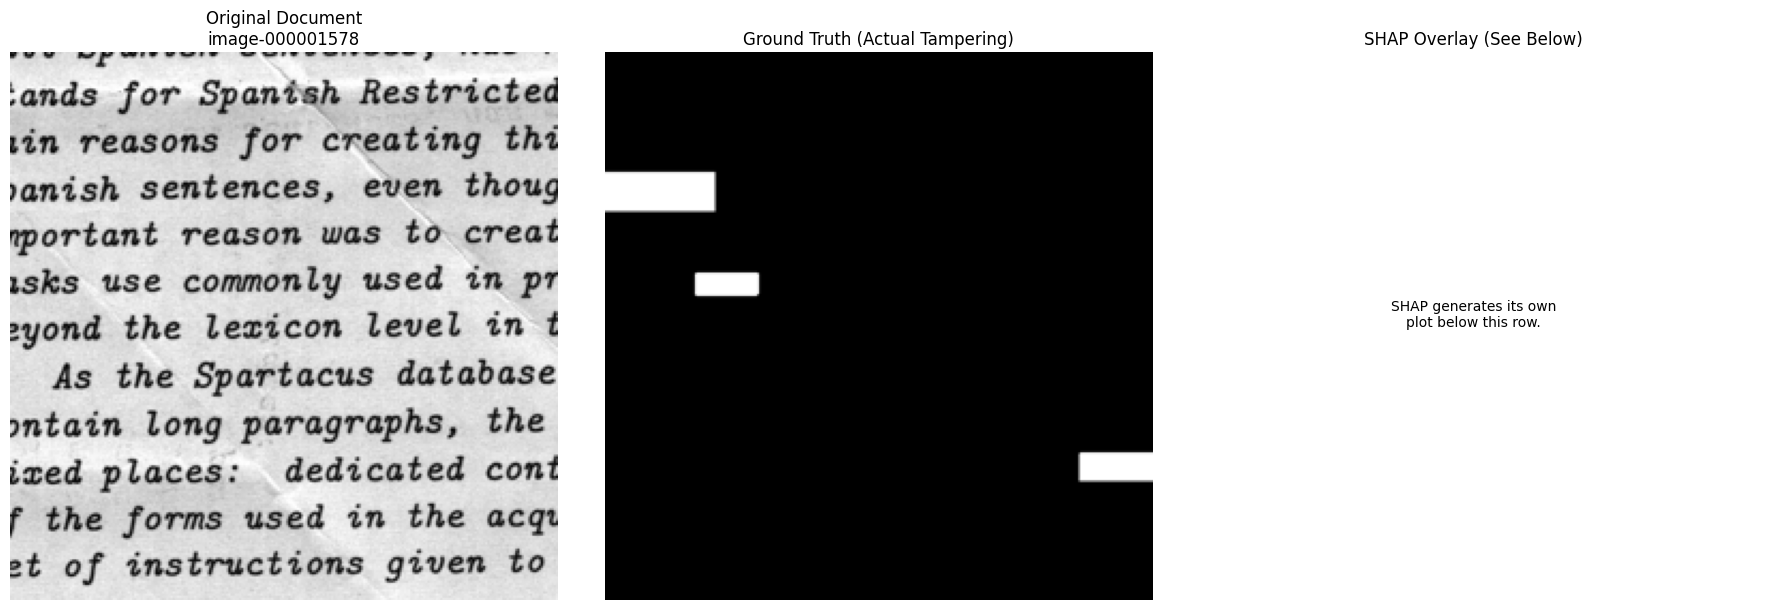

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.0].


SHAP Attribution (Red = Evidence of Fake):


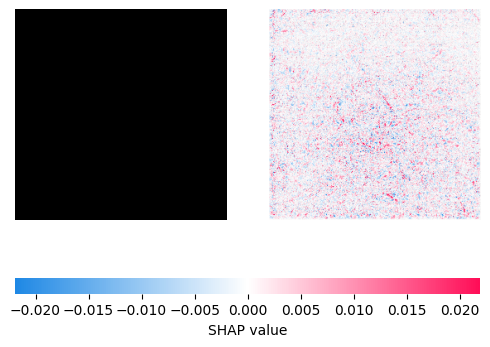

--------------------------------------------------------------------------------
--- Calculating SHAP for image-000001450 (2/3) ---


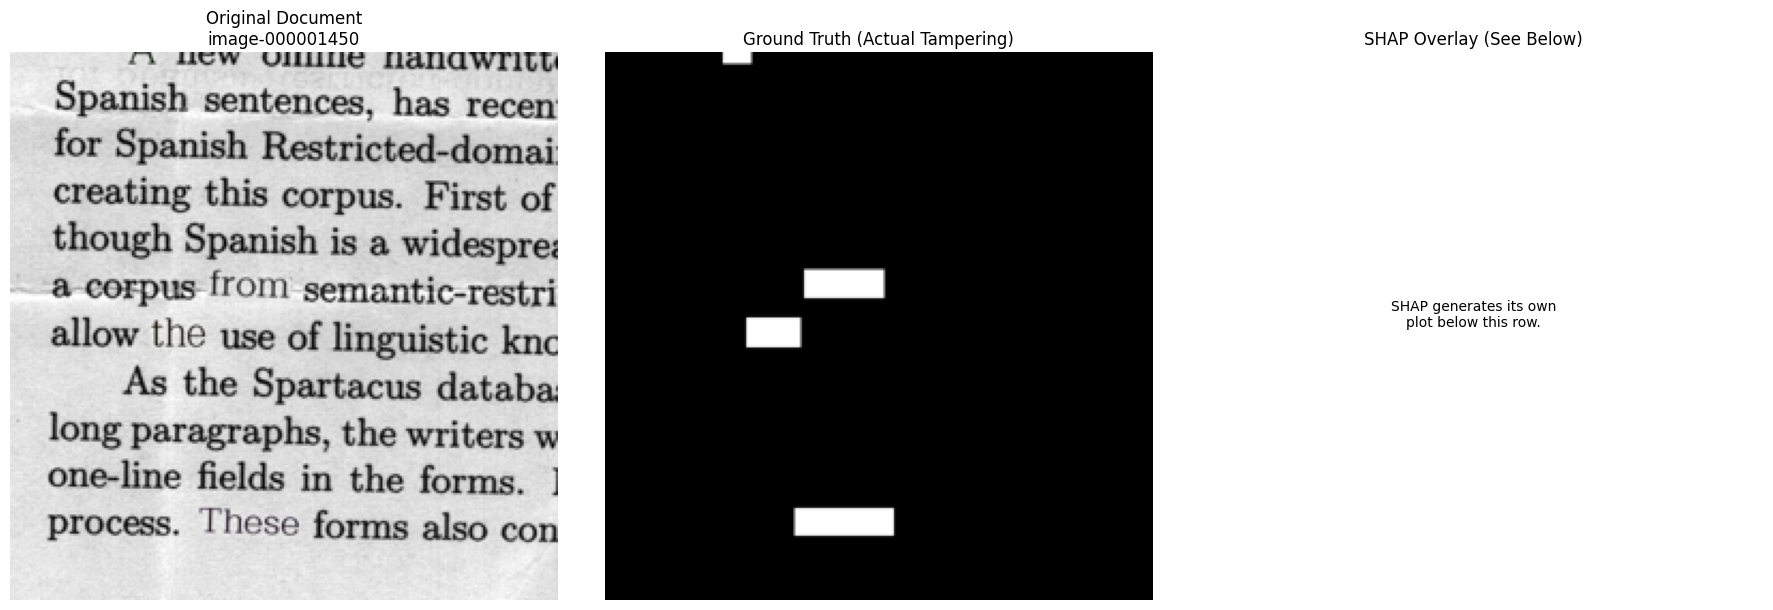

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.0].


SHAP Attribution (Red = Evidence of Fake):


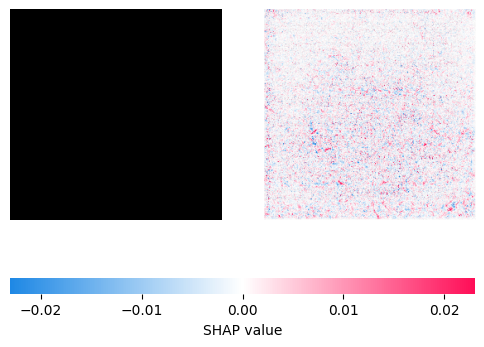

--------------------------------------------------------------------------------
--- Calculating SHAP for image-000002069 (3/3) ---
--- Calculating SHAP for image-000003176 (3/3) ---
--- Calculating SHAP for image-000001966 (3/3) ---


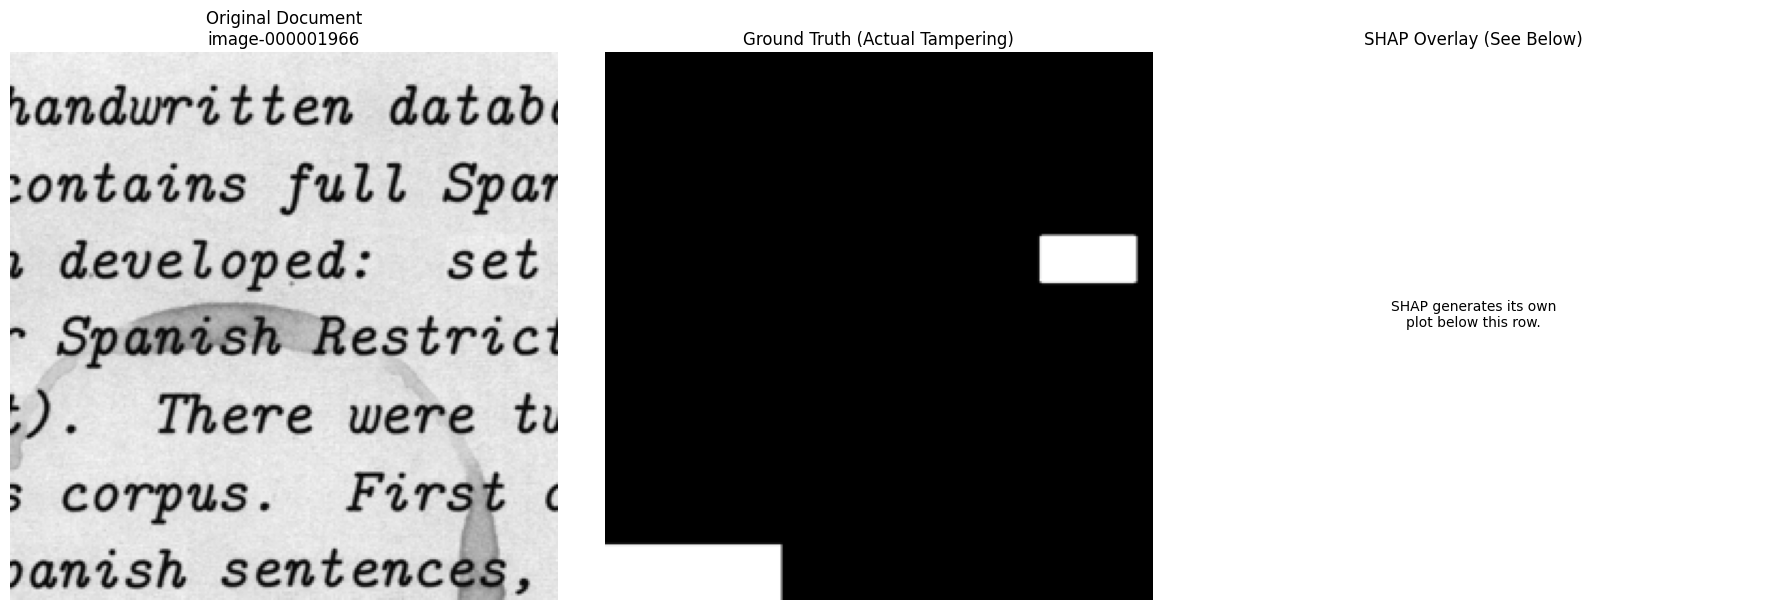

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.0].


SHAP Attribution (Red = Evidence of Fake):


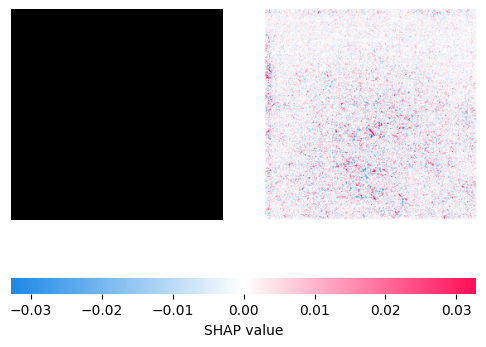

--------------------------------------------------------------------------------


In [21]:
# Cell 9 SHAP 3 column

import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import lmdb
import io
from PIL import Image

# --- 1. Setup SHAP Explainer ---
# (Only run this once. If 'explainer' already exists from previous cells, you can skip this block)
if 'ela_model' in locals() and 'explainer' not in locals():
    print("--- Initializing SHAP Explainer ---")
    def get_background_batch(dataset, n=50):
        loader = torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)
        images, labels = next(iter(loader))
        return images.to(device)
    
    background = get_background_batch(train_ds_ela, n=50)
    explainer = shap.GradientExplainer(ela_model, background)

# --- 2. Visualization Function (3-Column) ---
def visualize_shap_3_col(dataset, num_samples=3):
    count = 0
    inv_normalize = transforms.Normalize(
       mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
       std=[1/0.229, 1/0.224, 1/0.225]
    )

    for i in range(len(dataset)):
        if count >= num_samples: break
        
        ela_tensor, label = dataset[i]
        if label != 1: continue 
        
        lmdb_path, img_key, _ = dataset.data_list[i]
        mask_key = img_key.replace('image-', 'label-')
        print(f"--- Calculating SHAP for {img_key} ({count+1}/{num_samples}) ---")
        
        # A. Compute SHAP
        input_tensor = ela_tensor.unsqueeze(0).to(device)
        shap_values = explainer.shap_values(input_tensor)
        
        # Unpack list if needed
        if isinstance(shap_values, list): shap_numpy = shap_values[0]
        else: shap_numpy = shap_values
            
        # Fix Dimensions (Batch, C, H, W, Class) -> (Batch, H, W, C)
        if len(shap_numpy.shape) == 5: shap_numpy = np.squeeze(shap_numpy, axis=-1)
        
        if len(shap_numpy.shape) == 4:
            shap_display = np.transpose(shap_numpy, (0, 2, 3, 1))
        elif len(shap_numpy.shape) == 3:
            shap_display = np.transpose(shap_numpy, (1, 2, 0))
            shap_display = np.expand_dims(shap_display, axis=0)
        else: continue

        # B. Get Images (Original + Mask)
        try:
            env = lmdb.open(lmdb_path, readonly=True, lock=False)
            with env.begin() as txn:
                # Original
                img_bytes = txn.get(img_key.encode('utf-8'))
                original_numpy = np.array(Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((256, 256))) / 255.0
                
                # Mask
                mask_bytes = txn.get(mask_key.encode('utf-8'))
                gt_mask_pil = Image.open(io.BytesIO(mask_bytes)).convert('L').resize((256, 256))
            env.close()
        except: continue

        # C. Prepare ELA Background for SHAP Overlay
        ela_display = inv_normalize(ela_tensor).permute(1, 2, 0).cpu().numpy()
        ela_display = np.clip(ela_display, 0, 1)
        ela_display = np.expand_dims(ela_display, axis=0)
        
        # D. PLOTTING
        # We use a custom GridSpec or just manipulate the axes manually because
        # shap.image_plot doesn't play nice with subplots. 
        # TRICK: We will plot SHAP first, save it to a buffer, and then display it in the 3rd column.
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Col 1: Original
        axes[0].imshow(original_numpy)
        axes[0].set_title(f"Original Document\n{img_key}")
        axes[0].axis('off')
        
        # Col 2: Ground Truth
        axes[1].imshow(gt_mask_pil, cmap='gray')
        axes[1].set_title("Ground Truth (Actual Tampering)")
        axes[1].axis('off')
        
        # Col 3: SHAP
        # Since shap.image_plot forces a new figure, we can't easily put it into 'axes[2]'.
        # Instead, we leave axes[2] blank here and let SHAP print below.
        axes[2].axis('off')
        axes[2].set_title("SHAP Overlay (See Below)")
        axes[2].text(0.5, 0.5, "SHAP generates its own\nplot below this row.", ha='center')
        
        plt.tight_layout()
        plt.show()
        
        # Show SHAP immediately after
        print("SHAP Attribution (Red = Evidence of Fake):")
        shap.image_plot(shap_display, -ela_display)
        print("-" * 80)
        
        count += 1

if 'ela_model' in locals():
    visualize_shap_3_col(train_ds_ela, num_samples=3)